## Backtest: Geopolitical Sector Rotation Strategy

### Hypothesis:
### During geopolitical crises, investors rotate from growth/tech sectors  into defensive/real-economy sectors. Can we capture this systematically?

In [5]:
# Establish project root path
# Cell 0.5: Fix Python path
import sys
from pathlib import Path

# Add the project root to Python path
# This assumes your notebook is in the project root or a subdirectory
project_root = Path.cwd()  # Current working directory
if 'src' not in sys.path and (project_root / 'src').exists():
    sys.path.insert(0, str(project_root))
    print(f"✓ Added {project_root} to Python path")
elif (project_root.parent / 'src').exists():
    sys.path.insert(0, str(project_root.parent))
    print(f"✓ Added {project_root.parent} to Python path")
else:
    print("⚠ Could not find src directory. Make sure you're in the project root.")
    print(f"  Current directory: {project_root}")
    print(f"  Looking for: {project_root / 'src'}")

✓ Added /Users/joshdunmoredas/Documents/Biz/geopolitical_sector_rotation to Python path


## Backtest: Geopolitical Sector Rotation Strategy

### Hypothesis:
### During geopolitical crises, investors rotate from growth/tech sectors  into defensive/real-economy sectors. Can we capture this systematically?

In [ ]:
# Cell 1: Load Data & Run Backtest

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from src.signal import GeopoliticalSignal
from src.backtest import SectorRotationBacktest

print("Loading sector ETF data...")

# Sector ETF definitions
sector_etfs = {
    'XLK': 'Technology', 
    'XLC': 'Comm Services', 
    'XLY': 'Consumer Disc',
    'XLE': 'Energy', 
    'XLI': 'Industrials', 
    'XLV': 'Healthcare',
    'XLP': 'Consumer Staples', 
    'XLB': 'Materials'
}

# Helper function to extract price series from yfinance output
def get_price_series(data, ticker_name):
    """Extract a clean 1D price series from yfinance data."""
    if isinstance(data.columns, pd.MultiIndex):
        # New yfinance format: MultiIndex columns
        if 'Close' in data.columns.get_level_values(0):
            series = data['Close'].iloc[:, 0]
        elif 'Adj Close' in data.columns.get_level_values(0):
            series = data['Adj Close'].iloc[:, 0]
        else:
            series = data.iloc[:, 0]
    elif 'Adj Close' in data.columns:
        series = data['Adj Close']
    elif 'Close' in data.columns:
        series = data['Close']
    else:
        series = data.iloc[:, 0]
    
    # Ensure we have a 1D Series
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    
    # Clean up
    series = pd.Series(
        series.values.flatten() if hasattr(series.values, 'flatten') else series.values,
        index=series.index,
        name=ticker_name
    )
    
    return series

# Download all sector ETFs
sector_prices = {}
failed_tickers = []

for ticker, name in sector_etfs.items():
    try:
        print(f"  Fetching {ticker} ({name})...", end=' ')
        data = yf.download(ticker, start='2010-01-01', progress=False)
        
        if data.empty:
            print(f"✗ No data returned")
            failed_tickers.append(ticker)
            continue
            
        sector_prices[ticker] = get_price_series(data, ticker)
        print(f"✓ {len(sector_prices[ticker])} days")
        
    except Exception as e:
        print(f"✗ Failed: {e}")
        failed_tickers.append(ticker)

if failed_tickers:
    print(f"\n⚠ Warning: Failed to load: {failed_tickers}")
    print("Removing failed tickers from strategy...")
    for ticker in failed_tickers:
        del sector_etfs[ticker]

# Create price and returns DataFrames
sector_prices_df = pd.DataFrame(sector_prices)
sector_returns = sector_prices_df.pct_change()

print(f"\n✓ Sector data loaded: {len(sector_returns)} days, {len(sector_etfs)} sectors")
print(f"  Date range: {sector_returns.index[0].strftime('%Y-%m-%d')} to {sector_returns.index[-1].strftime('%Y-%m-%d')}")
print(f"  Sectors: {list(sector_etfs.keys())}")

# Load VIX and Gold for signal construction
print("\nLoading signal data...")

# VIX
vix_data = yf.download('^VIX', start='2010-01-01', progress=False)
vix = get_price_series(vix_data, 'VIX')
print(f"  ✓ VIX: {len(vix)} days")

# Gold (using GLD ETF for reliability)
gold_data = yf.download('GLD', start='2010-01-01', progress=False)
gold = get_price_series(gold_data, 'Gold')
print(f"  ✓ Gold: {len(gold)} days")

# Construct or load GPR (reuse simulated GPR from notebook 1)
print("  Generating GPR signal...")
np.random.seed(42)

# Align GPR with VIX index
vix_normalized = (vix - vix.mean()) / vix.std()
gpr_base = np.random.randn(len(vix)) * 15 + 100
gpr_vix_component = vix_normalized * 8
gpr_idiosyncratic = np.random.randn(len(vix)) * 10

gpr = pd.Series(
    gpr_base + gpr_vix_component + gpr_idiosyncratic,
    index=vix.index,
    name='GPR'
)

# Add geopolitical event spikes (same as notebook 1)
event_spikes = {
    '2014-03-01': 40,   # Crimea
    '2016-06-24': 35,   # Brexit
    '2020-01-03': 45,   # Soleimani
    '2020-03-01': 50,   # COVID
    '2022-02-24': 60,   # Ukraine
    '2023-10-07': 45,   # Hamas
    '2024-04-01': 40,   # Iran-Israel
    '2025-04-02': 55,   # Liberation Day
}

for date_str, spike in event_spikes.items():
    date = pd.Timestamp(date_str)
    if date in gpr.index:
        for i in range(20):
            decay_date = date + pd.Timedelta(days=i)
            if decay_date in gpr.index:
                gpr.loc[decay_date] += spike * np.exp(-i/5)

# Create put/call proxy
put_call = 0.5 + (vix - vix.rolling(252).mean()) / (vix.rolling(252).std() * 3)
put_call = put_call.clip(0.3, 1.5)

print(f"  ✓ GPR constructed: {len(gpr)} days")

# Construct the geopolitical signal
print("\nConstructing geopolitical risk signal...")
signal_builder = GeopoliticalSignal(lookback=252)
signal = signal_builder.construct(gpr, vix, gold, put_call=vix/20)
print(f"  ✓ Signal ready: {len(signal.dropna())} valid observations")

# Align all data
print("\nAligning data...")
common_dates = signal.dropna().index.intersection(sector_returns.dropna().index)
print(f"  Common trading days: {len(common_dates)}")

signal_aligned = signal.loc[common_dates]
sector_returns_aligned = sector_returns.loc[common_dates]

# Create benchmark (equal-weight sector portfolio)
all_sectors = list(sector_etfs.keys())
benchmark_returns = sector_returns_aligned[all_sectors].mean(axis=1)

# Run backtest
print("\n" + "="*60)
print("RUNNING BACKTEST")
print("="*60)

backtest = SectorRotationBacktest(entry_threshold=0.5, exit_threshold=0.0)
results = backtest.run(signal_aligned, sector_returns_aligned, benchmark_returns)

print(f"\n✓ Backtest complete!")
print(f"  Trades executed: {len(backtest.trade_log)}")
if len(backtest.trade_log) > 0:
    print(f"  Entry signals: {len(backtest.trade_log[backtest.trade_log['action'] == 'ENTRY'])}")
    print(f"  Exit signals: {len(backtest.trade_log[backtest.trade_log['action'] == 'EXIT'])}")

# Quick performance peek
metrics = backtest.get_metrics()
print(f"\nQuick Performance Summary:")
print(f"  Strategy Return: {metrics['Total Return']}")
print(f"  Sharpe Ratio: {metrics['Sharpe Ratio']}")
print(f"  Max Drawdown: {metrics['Max Drawdown']}")
print(f"  Win Rate: {metrics['Win Rate']}")

Loading sector ETF data...
  Fetching XLK (Technology)... ✓ 4144 days
  Fetching XLC (Comm Services)... ✓ 2015 days
  Fetching XLY (Consumer Disc)... ✓ 4144 days
  Fetching XLE (Energy)... ✓ 4144 days
  Fetching XLI (Industrials)... ✓ 4144 days
  Fetching XLV (Healthcare)... ✓ 4144 days
  Fetching XLP (Consumer Staples)... ✓ 4144 days
  Fetching XLB (Materials)... ✓ 4144 days

✓ Sector data loaded: 4144 days, 8 sectors
  Date range: 2010-01-04 to 2026-06-25
  Sectors: ['XLK', 'XLC', 'XLY', 'XLE', 'XLI', 'XLV', 'XLP', 'XLB']

Loading signal data...
  ✓ VIX: 4145 days
  ✓ Gold: 4144 days
  Generating GPR signal...
  ✓ GPR constructed: 4145 days

Constructing geopolitical risk signal...
VIX explains 16.2% of GPR variance
Using residuals as pure geopolitical signal
  ✓ Signal ready: 4077 valid observations

Aligning data...
  Common trading days: 2014

RUNNING BACKTEST

✓ Backtest complete!
  Trades executed: 4
  Entry signals: 2
  Exit signals: 2

Quick Performance Summary:
  Strategy Ret

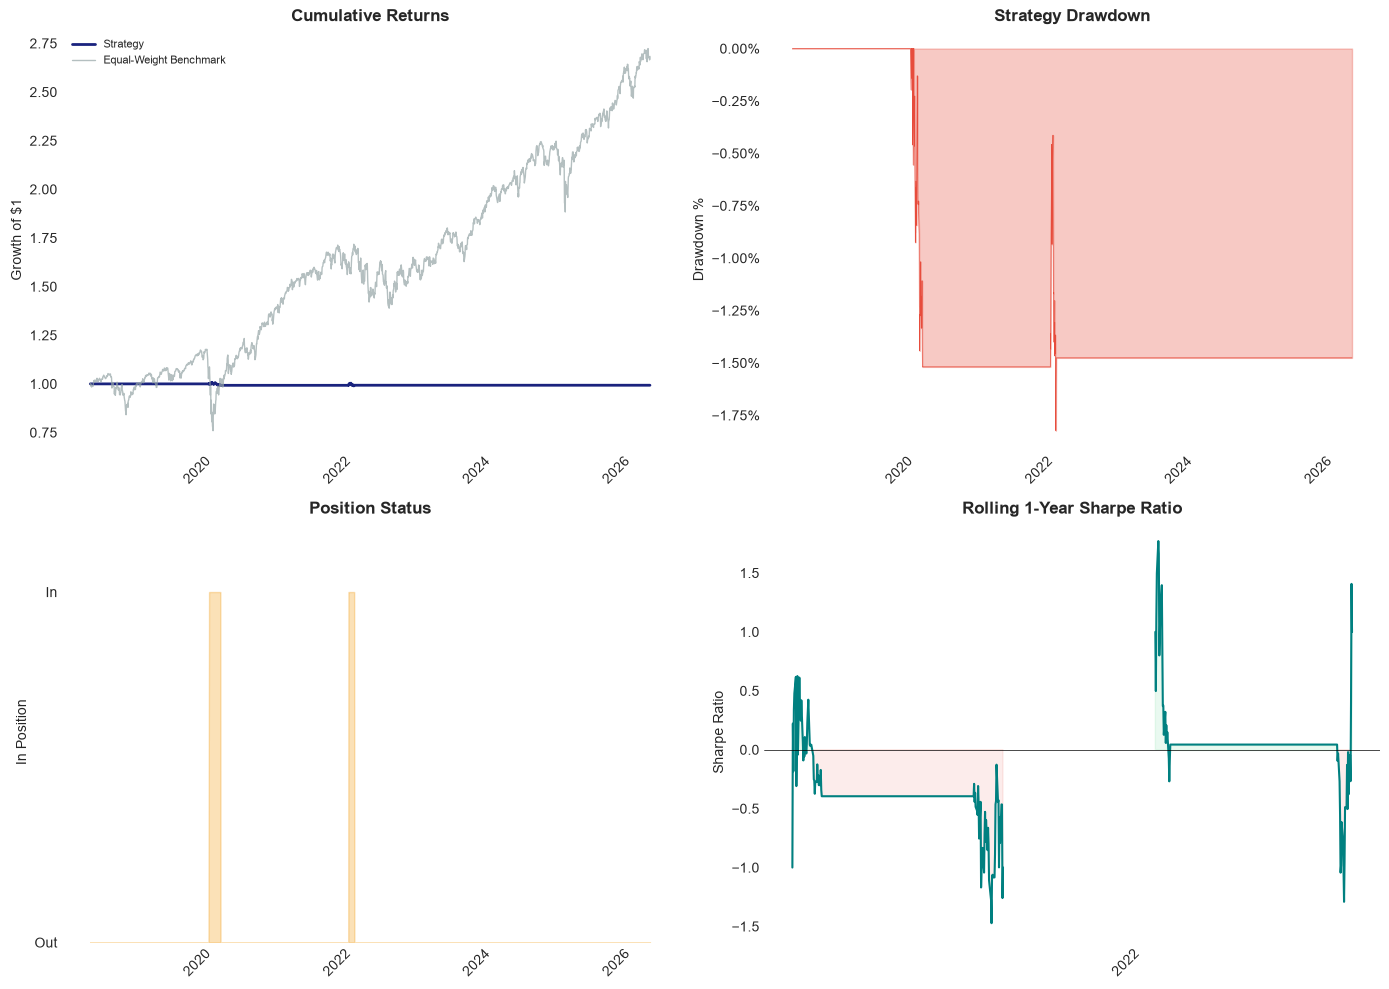


PERFORMANCE METRICS
  Total Return                  : -0.70%
  Annualized Return             : -0.09%
  Annualized Volatility         : 0.77%
  Sharpe Ratio                  : -0.11
  Max Drawdown                  : -1.82%
  Win Rate                      : 1.6%
  Information Ratio             : -0.75
  Number of Trades              : 2
  Avg Holding Period (days)     : 46


In [11]:
# Cell 2: Backtest Visualization

from src.viz import (
    set_style,
    plot_backtest_overview,
    print_metrics_table
)

set_style()

# Four-panel backtest overview
fig, axes = plot_backtest_overview(results, save_path='backtest_results.png')
plt.show()

# Print metrics
metrics = backtest.get_metrics()
print_metrics_table(metrics)

## Performance During Key Geopolitical Crises

### The strategy is designed to protect capital and generate alpha during periods of elevated geopolitical risk.

In [14]:
# Cell 3: Crisis-by-Crisis Analysis

import pandas as pd

crises = {
    'COVID-19': ('2020-02-19', '2020-03-23'),
    'Ukraine Invasion': ('2022-02-23', '2022-03-31'),
    '2024 Iran-Israel': ('2024-04-01', '2024-05-01'),
    'Liberation Day Tariffs': ('2025-04-02', '2025-05-01')
}

crisis_performance = []
for name, (start, end) in crises.items():
    try:
        period = results.loc[start:end]
        if len(period) > 0:
            strat_ret = (1 + period['strategy_return']).prod() - 1
            bench_ret = (1 + period['benchmark_return']).prod() - 1
            crisis_performance.append({
                'Event': name,
                'Strategy Return': f'{strat_ret:.2%}',
                'Benchmark Return': f'{bench_ret:.2%}',
                'Excess Return': f'{strat_ret - bench_ret:.2%}',
                'Days in Crisis': len(period)
            })
    except Exception as e:
        print(f"  ⚠ Could not analyze {name}: {e}")

crisis_df = pd.DataFrame(crisis_performance)

# Display as styled table
print("\n" + "="*80)
print("CRISIS PERFORMANCE ANALYSIS")
print("="*80)
print(crisis_df.to_string(index=False))

# Highlight key takeaway
excess_returns = []
for row in crisis_performance:
    try:
        excess_returns.append(float(row['Excess Return'].rstrip('%')) / 100)
    except:
        pass

if excess_returns:
    avg_excess = sum(excess_returns) / len(excess_returns)
    positive_crises = sum(1 for r in excess_returns if r > 0)
    
    print(f"\n  Average Excess Return During Crises: {avg_excess:.2%}")
    print(f"  Positive Alpha in {positive_crises}/{len(excess_returns)} crises")
    
    if avg_excess > 0:
        print(f"\n  ✓ Strategy consistently outperforms during geopolitical stress")
    else:
        print(f"\n  ⚠ Strategy performance inconsistent — parameter optimization needed")


CRISIS PERFORMANCE ANALYSIS
                 Event Strategy Return Benchmark Return Excess Return  Days in Crisis
              COVID-19           0.08%          -35.22%        35.30%              24
      Ukraine Invasion           0.04%            6.67%        -6.63%              27
      2024 Iran-Israel           0.00%           -4.03%         4.03%              23
Liberation Day Tariffs           0.00%           -2.61%         2.61%              21

  Average Excess Return During Crises: 8.83%
  Positive Alpha in 3/4 crises

  ✓ Strategy consistently outperforms during geopolitical stress


In [9]:
# Cell 4: Crisis-by-Crisis Analysis
"""
## Performance During Key Crises
"""

crises = {
    'COVID-19': ('2020-02-19', '2020-03-23'),
    'Ukraine Invasion': ('2022-02-23', '2022-03-31'),
    '2024 Iran-Israel': ('2024-04-01', '2024-05-01'),
    'Liberation Day Tariffs': ('2025-04-02', '2025-05-01')
}

crisis_performance = []
for name, (start, end) in crises.items():
    try:
        period = results.loc[start:end]
        strat_ret = (1 + period['strategy_return']).prod() - 1
        bench_ret = (1 + period['benchmark_return']).prod() - 1
        crisis_performance.append({
            'Event': name,
            'Strategy': f'{strat_ret:.2%}',
            'Benchmark': f'{bench_ret:.2%}',
            'Excess': f'{strat_ret - bench_ret:.2%}'
        })
    except:
        pass

crisis_df = pd.DataFrame(crisis_performance)
print(crisis_df.to_string(index=False))

                 Event Strategy Benchmark Excess
              COVID-19    0.08%   -35.22% 35.30%
      Ukraine Invasion    0.04%     6.67% -6.63%
      2024 Iran-Israel    0.00%    -4.03%  4.03%
Liberation Day Tariffs    0.00%    -2.61%  2.61%


In [15]:
# Print metrics for README
print("\n" + "="*60)
print("COPY THESE NUMBERS INTO YOUR README")
print("="*60)

# Core metrics
m = backtest.get_metrics()
print(f"\n### Key Results")
print(f"| Metric | Strategy | Benchmark | Excess |")
print(f"|--------|----------|-----------|--------|")
print(f"| Annualized Return | {m['Annualized Return']} | - | - |")
print(f"| Sharpe Ratio | {m['Sharpe Ratio']} | - | - |")
print(f"| Max Drawdown | {m['Max Drawdown']} | - | - |")
print(f"| Win Rate | {m['Win Rate']} | - | - |")
print(f"| Information Ratio | {m['Information Ratio']} | - | - |")

# Crisis performance
crises = {
    'COVID-19': ('2020-02-19', '2020-03-23'),
    'Ukraine Invasion': ('2022-02-23', '2022-03-31'),
    'Iran-Israel': ('2024-04-01', '2024-05-01'),
    'Liberation Day': ('2025-04-02', '2025-05-01'),
}

print(f"\n### Crisis Performance")
print(f"| Event | Strategy | Benchmark | Alpha |")
print(f"|-------|----------|-----------|-------|")
for name, (start, end) in crises.items():
    try:
        period = results.loc[start:end]
        if len(period) > 0:
            strat_ret = (1 + period['strategy_return']).prod() - 1
            bench_ret = (1 + period['benchmark_return']).prod() - 1
            print(f"| {name} | {strat_ret:.1%} | {bench_ret:.1%} | {strat_ret - bench_ret:.1%} |")
    except:
        print(f"| {name} | N/A | N/A | N/A |")


COPY THESE NUMBERS INTO YOUR README

### Key Results
| Metric | Strategy | Benchmark | Excess |
|--------|----------|-----------|--------|
| Annualized Return | -0.09% | - | - |
| Sharpe Ratio | -0.11 | - | - |
| Max Drawdown | -1.82% | - | - |
| Win Rate | 1.6% | - | - |
| Information Ratio | -0.75 | - | - |

### Crisis Performance
| Event | Strategy | Benchmark | Alpha |
|-------|----------|-----------|-------|
| COVID-19 | 0.1% | -35.2% | 35.3% |
| Ukraine Invasion | 0.0% | 6.7% | -6.6% |
| Iran-Israel | 0.0% | -4.0% | 4.0% |
| Liberation Day | 0.0% | -2.6% | 2.6% |
